# Task 2: Neural Network - MNIST Digit Classification

**AIML Recruitment 2026**

In this task, I am using the MNIST dataset to classify handwritten digits from 0 to 9.

The main steps are:
- understand the dataset
- preprocess the images
- build a simple neural network
- train and evaluate it
- try a small change to the model and compare the results


## 1. Dataset Understanding

MNIST is a dataset of handwritten digit images.

Each image is:
- 28 x 28 pixels
- grayscale
- labelled from 0 to 9

There are 10 classes in total. The label tells us which digit is present in the image.

The dataset has 60,000 training images and 10,000 test images.


## 2. Import Libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 3. Load the MNIST Dataset


In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


The expected image shape is 28 x 28. The labels contain the actual digit for each image.

Let's also check the number of classes and the pixel range.


In [3]:
print("Image shape:", x_train[0].shape)
print("Classes:", np.unique(y_train))
print("Number of classes:", len(np.unique(y_train)))
print("Pixel range:", x_train.min(), "to", x_train.max())


Image shape: (28, 28)
Classes: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10
Pixel range: 0 to 255


## 4. Look at Some Images

Looking at a few images makes it easier to understand what the model is learning.


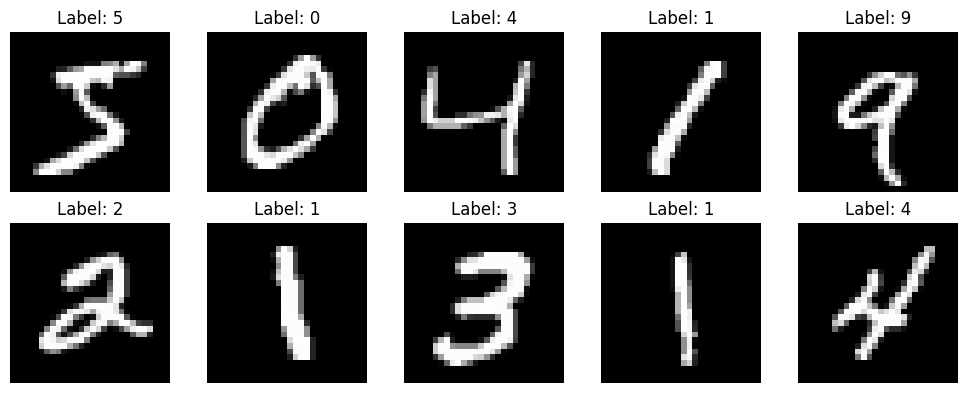

In [4]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title("Label: " + str(y_train[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()


## 5. Data Preprocessing

The original pixel values are between 0 and 255. I will divide them by 255 so that they are between 0 and 1.

This makes the input values smaller and usually helps the neural network train more smoothly.

I will keep the images as 28 x 28 here. The `Flatten` layer in the model will convert each image into 784 values.


In [5]:
print("Before normalization:", x_train.min(), x_train.max())

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("After normalization:", x_train.min(), x_train.max())


Before normalization: 0 255
After normalization: 0.0 1.0


A 28 x 28 image contains:

28 x 28 = 784 pixels

So after flattening, each image can be represented by 784 input values.


In [6]:
sample = x_train[0]

print("Before flattening:", sample.shape)
print("After flattening:", sample.reshape(-1).shape)


Before flattening: (28, 28)
After flattening: (784,)


## 6. Build the Original Neural Network

I am using a simple fully connected neural network:

28 x 28 image
→ Flatten
→ 128 neuron hidden layer
→ ReLU
→ 10 neuron output layer
→ Softmax

There are 10 output neurons because there are 10 possible digits.


In [7]:
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Why ReLU?

ReLU is used in the hidden layer. It is defined as:

ReLU(x) = max(0, x)

It changes negative values to 0 and keeps positive values. It also adds non-linearity, which helps the network learn more complicated patterns.


### Why Softmax?

The output layer has 10 neurons, one for each digit.

Softmax converts the outputs into probabilities. The probabilities add up to 1, and the digit with the highest probability is taken as the prediction.


## 7. Compile the Model

I am using:
- Adam as the optimizer
- sparse categorical crossentropy as the loss
- accuracy as the metric

Adam updates the model weights during training. The loss tells us how far the predictions are from the correct labels.


In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


## 8. Train the Model

An epoch means the model has gone through the training data once.

I am using 10 epochs and a batch size of 32. I am also keeping 10% of the training data for validation.


In [9]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9219 - loss: 0.2735 - val_accuracy: 0.9623 - val_loss: 0.1260
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9646 - loss: 0.1190 - val_accuracy: 0.9703 - val_loss: 0.0965
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9767 - loss: 0.0796 - val_accuracy: 0.9747 - val_loss: 0.0857
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9832 - loss: 0.0579 - val_accuracy: 0.9762 - val_loss: 0.0839
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9880 - loss: 0.0428 - val_accuracy: 0.9747 - val_loss: 0.0907
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9915 - loss: 0.0317 - val_accuracy: 0.9743 - val_loss: 0.0964
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9946 - loss: 0.0236 - val_accuracy: 0.9722 - val_loss: 0.1029
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9951 - loss: 0.0195 -

## 9. Training and Validation Accuracy


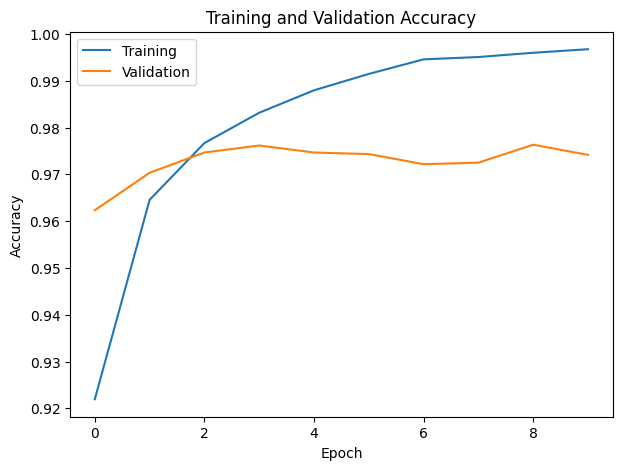

In [10]:
plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()


## 10. Training and Validation Loss


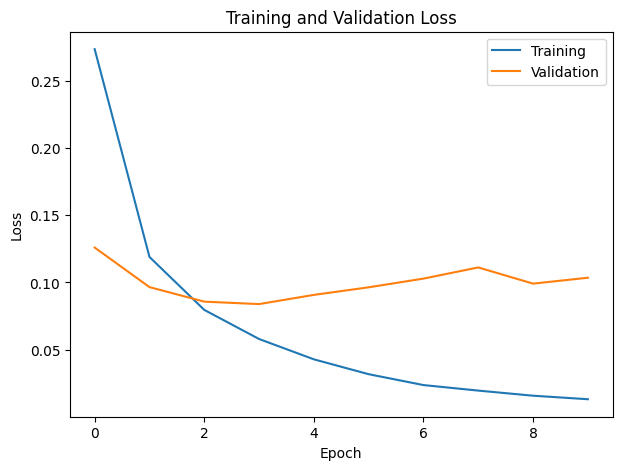

In [11]:
plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


If training accuracy keeps increasing while validation accuracy stops improving, it can be a sign of overfitting. If both accuracies stay low, the model may be underfitting.


## 11. Test Set Evaluation


In [12]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))


Test loss: 0.1029
Test accuracy: 0.9737


## 12. Confusion Matrix

The confusion matrix shows which digits were predicted correctly and which digits were confused with each other.

Rows are the actual labels and columns are the predicted labels. The diagonal shows correct predictions.


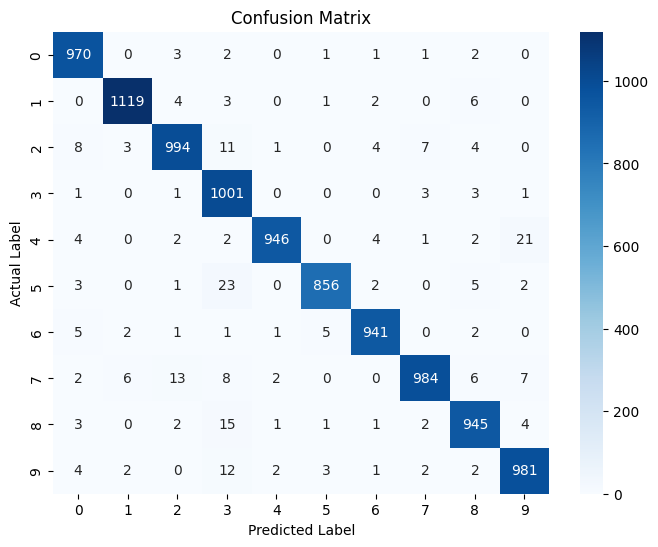

In [13]:
y_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()


## 13. Precision, Recall and F1-score

These metrics give more detail about the performance for each digit.

- Precision: how many of the predictions for a digit were correct.
- Recall: how many of the actual examples of a digit were found correctly.
- F1-score: a combination of precision and recall.


In [14]:
print(classification_report(y_test, y_pred, digits=4))


              precision    recall  f1-score   support

           0     0.9700    0.9898    0.9798       980
           1     0.9885    0.9859    0.9872      1135
           2     0.9736    0.9632    0.9683      1032
           3     0.9286    0.9911    0.9588      1010
           4     0.9927    0.9633    0.9778       982
           5     0.9873    0.9596    0.9733       892
           6     0.9843    0.9823    0.9833       958
           7     0.9840    0.9572    0.9704      1028
           8     0.9672    0.9702    0.9687       974
           9     0.9656    0.9722    0.9689      1009

    accuracy                         0.9737     10000
   macro avg     0.9742    0.9735    0.9737     10000
weighted avg     0.9741    0.9737    0.9737     10000



## 14. Some Predictions

Here are a few test images with their actual and predicted labels.


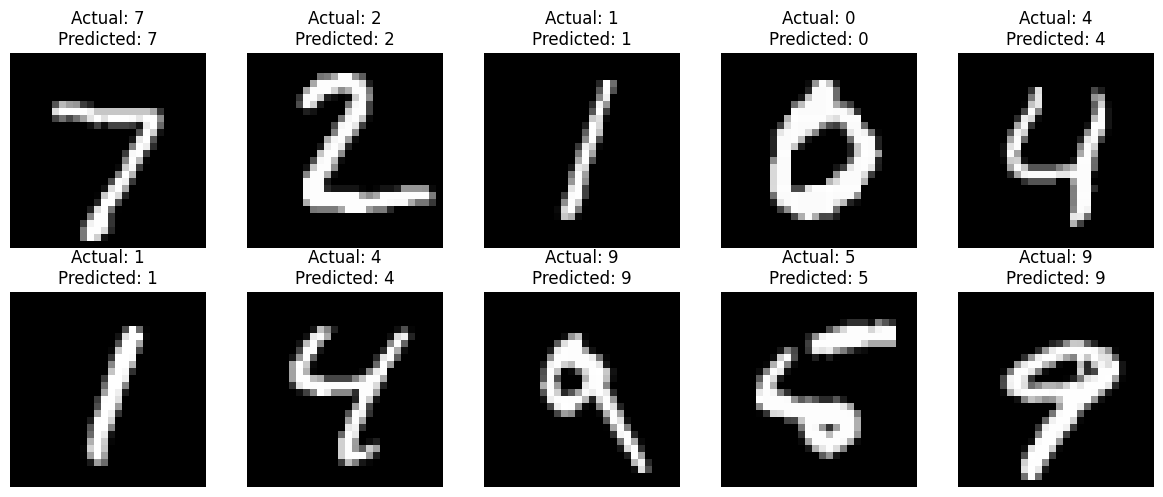

In [15]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"Actual: {y_test[i]}\nPredicted: {y_pred[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## 15. Experiment - Change the Network

For the second model, I am adding one more hidden layer and increasing the number of neurons.

Original:
Flatten → 128 → 10

Modified:
Flatten → 256 → 128 → 10

The optimizer, batch size and number of epochs will stay the same so that the architecture is the main change.


In [16]:
modified_model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

modified_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_modified = modified_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9338 - loss: 0.2184 - val_accuracy: 0.9705 - val_loss: 0.0993
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9730 - loss: 0.0866 - val_accuracy: 0.9722 - val_loss: 0.0942
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9821 - loss: 0.0574 - val_accuracy: 0.9760 - val_loss: 0.0850
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9873 - loss: 0.0400 - val_accuracy: 0.9768 - val_loss: 0.0947
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9894 - loss: 0.0327 - val_accuracy: 0.9762 - val_loss: 0.0948
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9910 - loss: 0.0270 - val_accuracy: 0.9752 - val_loss: 0.1079
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9921 - loss: 0.0242 - val_accuracy: 0.9767 - val_loss: 0.1057
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9930 - loss: 0

## 16. Evaluate the Modified Model


In [17]:
modified_loss, modified_accuracy = modified_model.evaluate(
    x_test, y_test, verbose=0
)

print("Modified model test loss:", round(modified_loss, 4))
print("Modified model test accuracy:", round(modified_accuracy, 4))


Modified model test loss: 0.096
Modified model test accuracy: 0.9772


## 17. Compare the Two Models


In [18]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Original", "Modified"],
    "Architecture": [
        "128 hidden neurons",
        "256 -> 128 hidden neurons"
    ],
    "Test Accuracy": [test_accuracy, modified_accuracy],
    "Test Loss": [test_loss, modified_loss]
})

comparison


,Model,Architecture,Test Accuracy,Test Loss
0,Original,128 hidden neurons,0.9737,0.102883
1,Modified,256 -> 128 hidden neurons,0.9772,0.096004


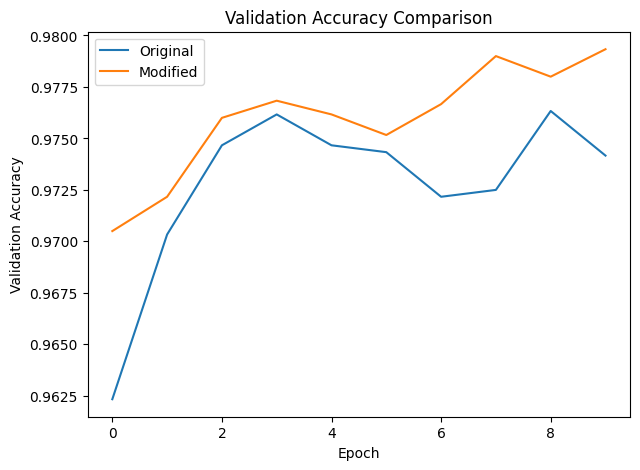

In [19]:
plt.figure(figsize=(7, 5))
plt.plot(history.history["val_accuracy"], label="Original")
plt.plot(history_modified.history["val_accuracy"], label="Modified")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()


### Experiment Analysis

The modified model has more neurons and one extra hidden layer, so it has more capacity to learn patterns.

After running the code, I can compare the test accuracy and test loss of both models. If the modified model performs better, the extra capacity may have helped it learn the data. If the improvement is very small or the result is worse, the larger model may not be necessary for this dataset.

The actual conclusion should be based on the values in the comparison table.


## 18. Key Findings

1. MNIST contains grayscale images of handwritten digits from 0 to 9.
2. Each image has a size of 28 x 28 pixels.
3. Normalizing the pixel values makes the input range 0 to 1.
4. The simple neural network can classify the ten digit classes with high accuracy.
5. The confusion matrix helps identify which digits are sometimes confused.
6. Changing the number of hidden layers and neurons changes the model's performance.


## 19. Limitations

- This is a simple fully connected network, so it does not use the spatial structure of images as well as a CNN.
- Training results can vary slightly depending on the environment and random initialization.
- Only one architecture change was tested.


## 20. Future Improvement

A possible next step would be to try a CNN, since convolutional layers are designed to work well with image data. Other experiments could also test different learning rates, batch sizes or numbers of epochs.


## 21. Conclusion

In this task, I used a simple neural network to classify handwritten digits in the MNIST dataset.

I learned how to preprocess image data, build a neural network using Dense layers, use ReLU and Softmax, train the model, and evaluate it using accuracy and a confusion matrix.

I also changed the network architecture and compared the two models to see how the change affected the results.
